# In case of any error: 
Please access the link to my GitHub.


In [5]:
import pandas as pd 
import numpy as np
import datetime as datetime
import glob
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Preparing the data

## Creating a directory

In [6]:
path = r"C:\Users\Chant\Data Files"

files = glob.glob(path + "*.cvs")

Data_Sets = [pd.read_csv(file) for file in files]

## Checking if the directory works

In [7]:
path = r"C:\Users\Chant\Data Files"

files = glob.glob(path + r"\*.csv")

if not files:
    print("No files found in the directory.")
else:
    print(f"Found {len(files)} files.")

    datasets = [pd.read_csv(file) for file in files]
    for i, df in enumerate(datasets):
        print(f"Dataset {i+1} from file {files[i]}:")
        print(df.head()) 
        print("\n")


Found 16 files.
Dataset 1 from file C:\Users\Chant\Data Files\combined_data.csv:
          Date  Actual  Goal
0  May 31 2022       0  8000
1   Jun 1 2022       0  8000
2   Jun 2 2022       0  8000
3   Jun 3 2022    1102  8000
4   Jun 4 2022    1254  8000


Dataset 2 from file C:\Users\Chant\Data Files\Steps1.csv:
          Date  Actual  Goal
0  May 31 2022       0  8000
1   Jun 1 2022       0  8000
2   Jun 2 2022       0  8000
3   Jun 3 2022    1102  8000
4   Jun 4 2022    1254  8000


Dataset 3 from file C:\Users\Chant\Data Files\Steps10.csv:
          Date  Actual  Goal
0   Feb 7 2023    5417  8000
1   Feb 8 2023    3397  8000
2   Feb 9 2023   15341  8000
3  Feb 10 2023    8071  8000
4  Feb 11 2023    1392  8000


Dataset 4 from file C:\Users\Chant\Data Files\Steps11.csv:
          Date  Actual  Goal
0   Mar 7 2023    7521  8000
1   Mar 8 2023    9689  8000
2   Mar 9 2023    4166  8000
3  Mar 10 2023    5735  8000
4  Mar 11 2023    2007  8000


Dataset 5 from file C:\Users\Chant\Data

## Combining the files into one

In [12]:
all_Files = glob.glob(path + "/*.csv")

dataFile_List = []
for file in all_Files: 
    df = pd.read_csv(file)
    if not df.empty: 
        dataFile_List.append(df)
    else:
        print(f"File {file} is empty and shall be skipped.")
        
if dataFile_List:
    concat_files = pd.concat(dataFile_List, ignore_index = True)
    print("Data frame has successfully been concatenated.") 
    print("Combined DataFrame:", concat_files.head())
    concat_files.to_csv(r"C:\Users\Chant\Data Files\combined_data.csv", index=False)
else:
    print("The are no valid data frames to concatenate.")

Data frame has successfully been concatenated.
Combined DataFrame:           Date  Actual  Goal
0  May 31 2022       0  8000
1   Jun 1 2022       0  8000
2   Jun 2 2022       0  8000
3   Jun 3 2022    1102  8000
4   Jun 4 2022    1254  8000


## Checking for Missing Values 

In [9]:
print("Missing Values in each column")
print(df.isnull().sum())

Missing Values in each column
Date      0
Actual    0
Goal      0
dtype: int64


## Checking the total number of rows

In [2]:
combined_DataFrame = pd.read_csv(r"C:\Users\Chant\Data Files\combined_data.csv")

total_rows = combined_DataFrame.shape[0]
print("The total number of rows in the combined CSV File:", total_rows)

The total number of rows in the combined CSV File: 420


# Cleaning the data

## Changing the format of the date

In [35]:
combined_DataFrame = pd.read_csv(r"C:\Users\Chant\Data Files\combined_data.csv")
combined_DataFrame['Date'] = pd.to_datetime(combined_DataFrame['Date'], format='%b %d %Y', errors='coerce')

## Setting an index 

In [36]:
combined_DataFrame = pd.read_csv(r"C:\Users\Chant\Data Files\combined_data.csv")
combined_DataFrame.set_index('Date', inplace=True)

## Checking for accuracy 

In [37]:
combined_DataFrame = pd.read_csv(r"C:\Users\Chant\Data Files\combined_data.csv")
combined_DataFrame = combined_DataFrame.sort_values(by='Date', ascending = False)
print(combined_DataFrame)

            Date  Actual  Goal
269   Sep 9 2022   12348  8000
268   Sep 8 2022    5735  8000
267   Sep 7 2022    5364  8000
266   Sep 6 2022    7586  8000
265   Sep 5 2022    7863  8000
..           ...     ...   ...
93   Apr 13 2023    2251  8000
92   Apr 12 2023    5214  8000
91   Apr 11 2023    5418  8000
90   Apr 10 2023    6700  8000
81    Apr 1 2023   10345  8000

[420 rows x 3 columns]


# Exploratory Data Analysis (EDA) 

## Visualizing the time series of daily steps

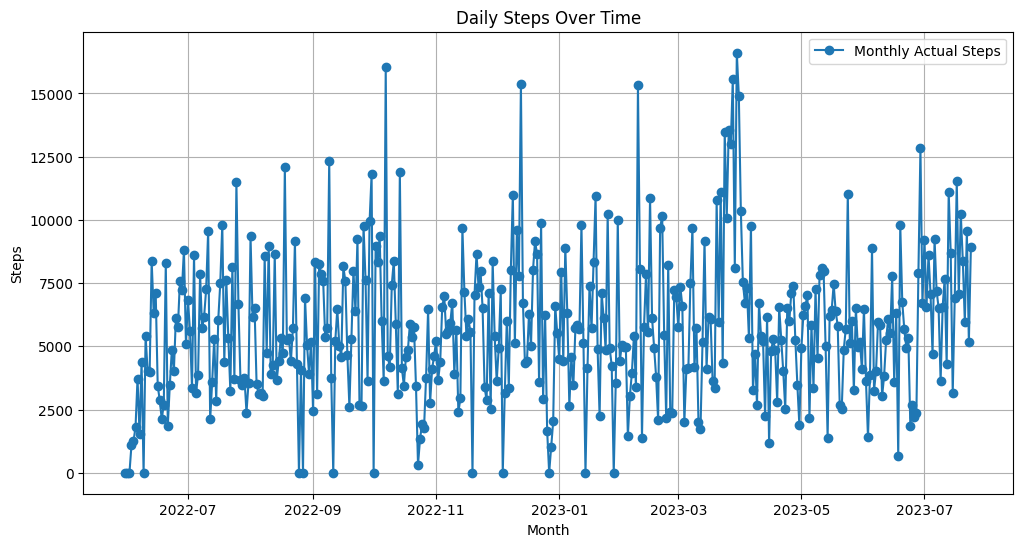

In [36]:
combined_DataFrame = pd.read_csv(r"C:\Users\Chant\Data Files\combined_data.csv")

combined_DataFrame['Date'] = pd.to_datetime(combined_DataFrame['Date'], format='%b %d %Y', errors='coerce')

combined_DataFrame.set_index('Date', inplace=True)

daily_data = combined_DataFrame.resample('D').sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_data.index, daily_data['Actual'], marker='o', label='Monthly Actual Steps')
plt.title('Daily Steps Over Time')
plt.xlabel('Month')
plt.ylabel('Steps')
plt.legend()
plt.grid()
plt.show()

## Desciptive Statistics

### Frequency Distribution

In [37]:
frequency_distribution = combined_DataFrame['Actual'].value_counts().head(10)
print("\nFrequency distribution of the top 10 most common step counts:", frequency_distribution)


Frequency distribution of the top 10 most common step counts: Actual
0       13
3445     2
2532     2
3634     2
4137     2
5266     2
7114     2
6555     2
8657     2
5735     2
Name: count, dtype: int64


### Checking for the skewness

In [38]:
skewness = combined_DataFrame['Actual'].skew()
print(f"Skewness of daily steps: {skewness}")

Skewness of daily steps: 0.6762482850303565


### Chebyshev's Theorem

In [39]:
k = 2
chebyshev_bound = 1 - (1 / k**2)
print(f"Chebyshev's Theorem (k=2): At least {chebyshev_bound * 100:.2f}% of the data lies within 2 standard deviations from the mean.")

Chebyshev's Theorem (k=2): At least 75.00% of the data lies within 2 standard deviations from the mean.


### Median Absolute Deviation (MAD) of daily steps

In [40]:
median_value = combined_DataFrame['Actual'].median()
mad = combined_DataFrame['Actual'].apply(lambda x: np.abs(x - median_value)).median()
print(f"Median Absolute Deviation (MAD) of daily steps: {mad}")

Median Absolute Deviation (MAD) of daily steps: 1819.0


### Descriptive Statistics for Actual Steps

In [41]:
print("Descriptive Statistics for Actual Steps:")
print(combined_DataFrame['Actual'].describe())

Descriptive Statistics for Actual Steps:
count      420.000000
mean      5674.140476
std       2930.565439
min          0.000000
25%       3634.000000
50%       5402.000000
75%       7349.000000
max      16611.000000
Name: Actual, dtype: float64


# Testing for seasonality

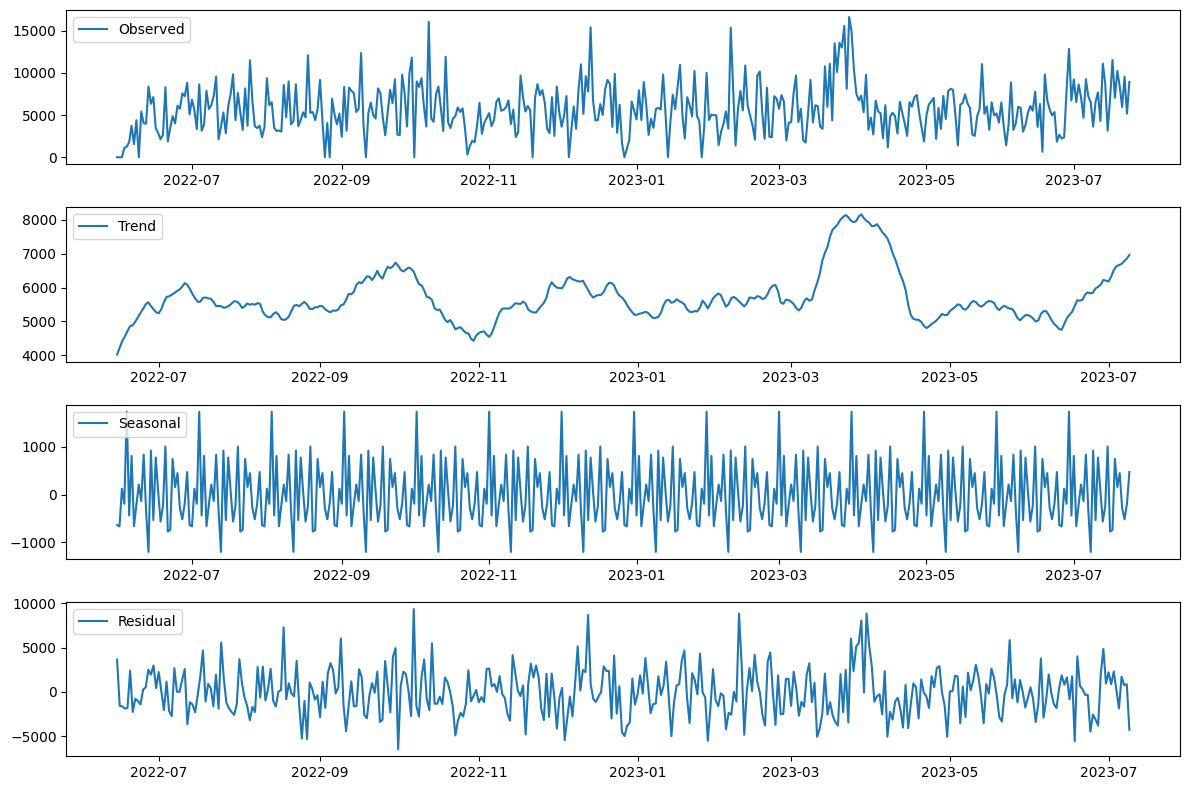

ADF Statistic: -4.831054414326104
p-value: 4.741516040666662e-05
The time series is stationary.


In [42]:
combined_DataFrame = combined_DataFrame.asfreq('D')

decomposition = seasonal_decompose(combined_DataFrame['Actual'], model='additive', period=30)

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residual')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


adf_test = adfuller(combined_DataFrame['Actual'].dropna())
adf_statistic = adf_test[0]
p_value = adf_test[1]

print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')


if p_value < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")


#### With the ADF Stat having a -4.83 value indicates that and the p value of 4.74, it is reinforcing the fact that the data is stationary indicating that the mean and variance have not chnaged over time, which is an essential assumption before proceeding with the calculations further. 

                               SARIMAX Results                                
Dep. Variable:                 Actual   No. Observations:                  420
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -3929.532
Date:                Tue, 13 Aug 2024   AIC                           7867.064
Time:                        16:45:32   BIC                           7883.225
Sample:                             0   HQIC                          7873.452
                                - 420                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5674.1402    314.658     18.033      0.000    5057.422    6290.859
ar.L1          0.8725      0.064     13.718      0.000       0.748       0.997
ma.L1         -0.7160      0.090     -7.991      0.0

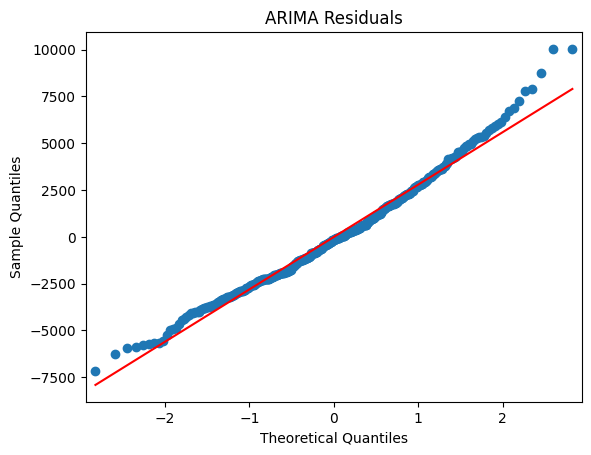

In [38]:
combined_DataFrame.sort_index(inplace=True)
arima_order = (1, 0, 1) 
arima_model = ARIMA(combined_DataFrame['Actual'], order=arima_order)
arima_res = arima_model.fit()

print(arima_res.summary())

resid = arima_res.resid
sm.qqplot(resid, line='s')
plt.title('ARIMA Residuals')
plt.show()

#### If we look at the Ljung-Box test, it rather suggests that the residuals are uncorrelated, which is then good for this analysis. Another key test is the Jarque-Bera test which indicates that the residuals are approximately are normally distributed.  

                                     SARIMAX Results                                      
Dep. Variable:                             Actual   No. Observations:                  420
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -3832.150
Date:                            Tue, 13 Aug 2024   AIC                           7672.301
Time:                                    16:45:47   BIC                           7688.336
Sample:                                         0   HQIC                          7678.647
                                            - 420                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0553      0.059      0.935      0.350      -0.061       0.171
ma.L1         -0.8502      0.031   

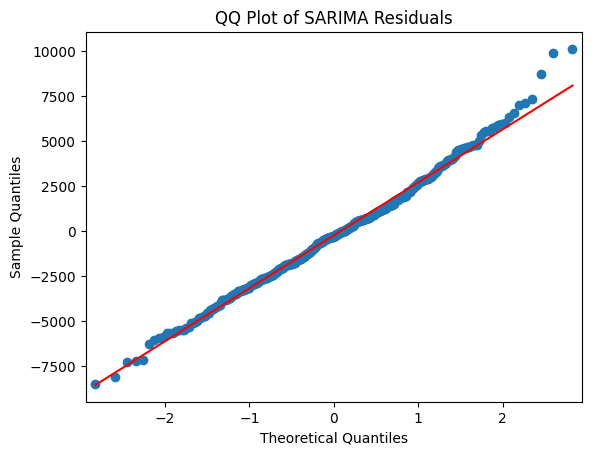

In [39]:
combined_DataFrame.sort_index(inplace=True)
sarima_order = (1, 1, 1)  
seasonal_order = (0, 1, 1, 12)  
sarima_model = SARIMAX(combined_DataFrame['Actual'], order=sarima_order, seasonal_order=seasonal_order)
sarima_res = sarima_model.fit()

print(sarima_res.summary())

residuals_sarima = sarima_res.resid
sm.qqplot(residuals_sarima, line='s')
plt.title('SARIMA Residuals')
plt.show()

#### The Ljung-Box test suggests no significant autocorrelation in residuals, which is good. However, the Jarque-Bera test indicates that residuals are not perfectly normally distributed. 

In [90]:
print(f'ARIMA AIC: {arima_res.aic}')
print(f'SARIMA AIC: {sarima_res.aic}')

if arima_res.aic < sarima_res.aic:
    print("\nARIMA emerges as the most effective model, demonstrating superior performance compared to SARIMA.")
else:
    print("\nSARIMA emerges as the most effective model, demonstrating superior performance compared to ARIMA.")

ARIMA AIC: 7867.064129685289
SARIMA AIC: 7669.401987711504

SARIMA emerges as the most effective model, demonstrating superior performance compared to ARIMA.


#### Based on the AIC values, I’ve found that SARIMA is the better model for my data. The lower AIC indicates a better fit with fewer parameters, making SARIMA more efficient for forecasting compared to ARIMA. To further validate this, I might consider cross-validation or testing the model with out-of-sample data. 

In [41]:
print("The data frame after filtering up to 24 June 2023:")
print(combined_DataFrame)

print("\nThe date index of data frame:")
print(combined_DataFrame.index)

if len(combined_DataFrame) > 0:
    print("\nThe last date in the data frame:", combined_DataFrame.index[-1])
else:
    print("The data frame is empty.")

The data frame after filtering up to 24 June 2023:
            Date  Actual  Goal
0    May 31 2022       0  8000
1     Jun 1 2022       0  8000
2     Jun 2 2022       0  8000
3     Jun 3 2022    1102  8000
4     Jun 4 2022    1254  8000
..           ...     ...   ...
415   Feb 2 2023    4969  8000
416   Feb 3 2023    4979  8000
417   Feb 4 2023    1441  8000
418   Feb 5 2023    3025  8000
419   Feb 6 2023    3956  8000

[420 rows x 3 columns]

The date index of data frame:
Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       410, 411, 412, 413, 414, 415, 416, 417, 418, 419],
      dtype='int64', length=420)

The last date in the data frame: 419


In [84]:
combined_DataFrame.sort_index(inplace=True)

## Forecasting 

### SARIMA Forecasting 

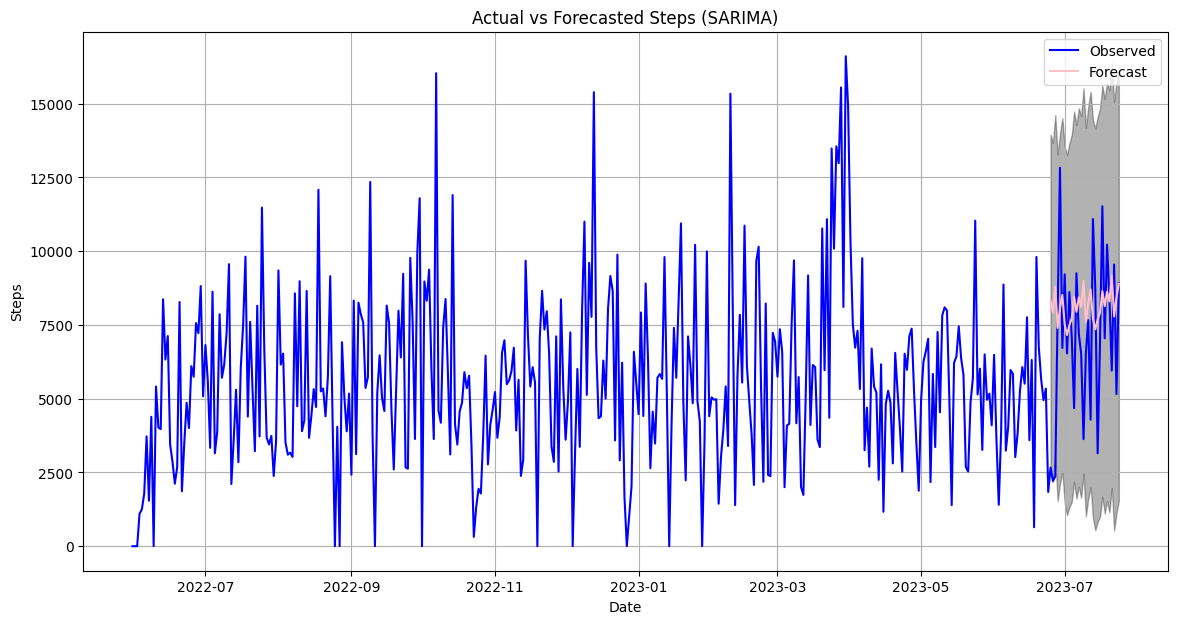

Mean Squared Error (MSE): 9276692.029041188
R-squared: -0.27838265869411183


In [24]:
if 'Date' in combined_DataFrame.columns:
    combined_DataFrame['Date'] = pd.to_datetime(combined_DataFrame['Date'], format='%b %d %Y', errors='coerce')


if combined_DataFrame.index.name != 'Date':
    combined_DataFrame.set_index('Date', inplace=True)


combined_DataFrame = combined_DataFrame.asfreq('D')

sarima_order = (1, 1, 1)  
seasonal_order = (0, 1, 1, 12)  

sarima_model = SARIMAX(combined_DataFrame['Actual'], order=sarima_order, seasonal_order=seasonal_order)
sarima_res = sarima_model.fit()

forecast_start_date = pd.Timestamp('2023-06-25')
forecast_steps = 30


if forecast_start_date < combined_DataFrame.index.min():
    print("Error: Forecast start date is before the data range.")
elif forecast_start_date > combined_DataFrame.index.max():
    print("Error: Forecast start date is beyond the data range.")
    forecast_start_date = combined_DataFrame.index.max()

forecast_index = pd.date_range(start=forecast_start_date, periods=forecast_steps, freq='D')

forecast = sarima_res.get_forecast(steps=forecast_steps)
forecast_series = pd.Series(forecast.predicted_mean.values, index=forecast_index)
conf_int = forecast.conf_int()


actual_series = combined_DataFrame['Actual'].reindex(forecast_index)


if actual_series.isna().all():
    print("Warning: No actual data available for the forecasted period.")
else:
    plt.figure(figsize=(14, 7))
    plt.plot(combined_DataFrame.index, combined_DataFrame['Actual'], label='Observed', color='blue')
    plt.plot(forecast_series, label='Forecast', color='pink')
    plt.fill_between(forecast_series.index, 
                     conf_int.iloc[:, 0], 
                     conf_int.iloc[:, 1], 
                     color='black', alpha=0.3)
    plt.title('Actual vs Forecasted Steps (SARIMA)')
    plt.xlabel('Date')
    plt.ylabel('Steps')
    plt.legend()
    plt.grid(True)
    plt.show()

    comparison_df = pd.DataFrame({'Actual': actual_series, 'Forecast': forecast_series})
    comparison_df = comparison_df.dropna()

    if comparison_df.empty:
        print("Error: Comparison DataFrame is empty after dropping NaN values.")
    else:

        mse = mean_squared_error(comparison_df['Actual'], comparison_df['Forecast'])
        r2 = r2_score(comparison_df['Actual'], comparison_df['Forecast'])

        print(f'Mean Squared Error (MSE): {mse}')
        print(f'R-squared: {r2}')


#### Based on the performance metrics of my SARIMA model:

- **Mean Squared Error (MSE):** 9,276,692.03
- **R-squared:** -0.278

The MSE is relatively high, indicating that my model's predictions have a significant amount of error on average. This suggests that the model may not be capturing the underlying patterns in the data very well, and adjustments or a different model might be needed.

The R-squared value is negative, which is unusual since R-squared typically ranges from 0 to 1 for well-fitting models. A negative R-squared value means my model is performing worse than a simple mean-based model. This indicates that the SARIMA model might not be the best fit for the data, and exploring alternative models or additional tuning might be necessary.

In summary, while SARIMA appears to be more effective based on AIC values, these error metrics suggest there might still be room for improvement in terms of accuracy.

## Forecasting with Prophet

20:21:53 - cmdstanpy - INFO - Chain [1] start processing
20:21:53 - cmdstanpy - INFO - Chain [1] done processing


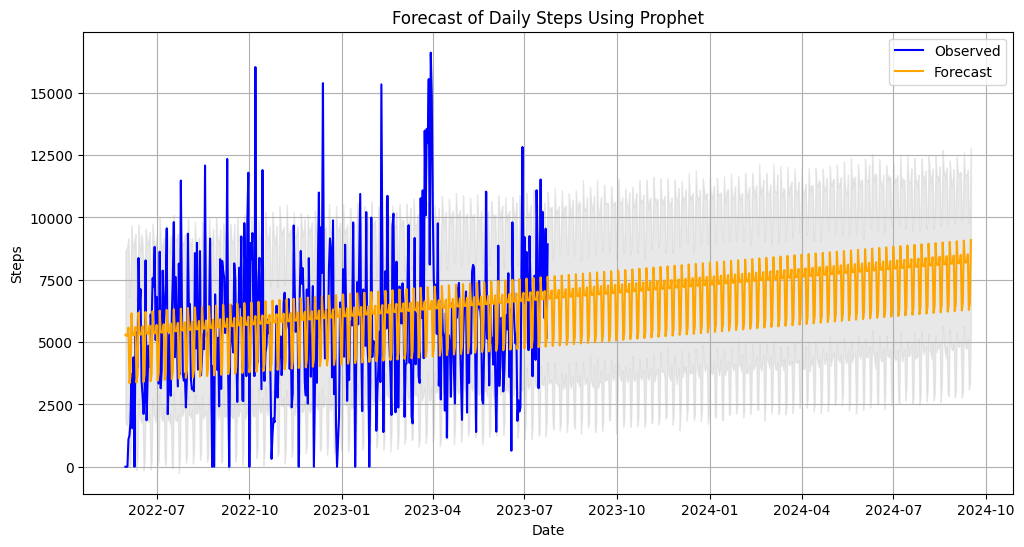

Prophet Mean Squared Error (MSE): 7472976.8586
Prophet R-squared: 0.1278


In [31]:
combined_DataFrame.sort_index(inplace=True)

prophet_dataf = combined_DataFrame.reset_index()[['Date', 'Actual']].rename(columns={'Date': 'ds', 'Actual': 'y'})
prophet_dataf['ds'] = pd.to_datetime(prophet_dataf['ds'], errors='coerce')
prophet_dataf.dropna(subset=['ds'], inplace=True)

model = Prophet()
model.fit(prophet_dataf)

forecast_periods = len(prophet_dataf)
future = model.make_future_dataframe(periods=forecast_periods)
forecast_prophet = model.predict(future)


plt.figure(figsize=(12, 6))
plt.plot(prophet_dataf['ds'], prophet_dataf['y'], label='Observed', color='blue')
plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label='Forecast', color='orange')
plt.fill_between(forecast_prophet['ds'], 
                 forecast_prophet['yhat_lower'], 
                 forecast_prophet['yhat_upper'], 
                 color='lightgray', alpha=0.5)
plt.title('Forecast of Daily Steps Using Prophet')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.legend()
plt.grid(True)
plt.show()

forecasted_range = forecast_prophet[forecast_prophet['ds'] >= prophet_dataf['ds'].min()]
forecasted_values = forecasted_range['yhat'].values[:len(prophet_dataf)]
actual_values = prophet_dataf['y'].values

if len(forecasted_values) == len(actual_values):
    mse_prophet = mean_squared_error(actual_values, forecasted_values)
    r_squared_prophet = r2_score(actual_values, forecasted_values)

    print(f'Prophet Mean Squared Error (MSE): {mse_prophet:.4f}')
    print(f'Prophet R-squared: {r_squared_prophet:.4f}')
else:
    print(f"Length mismatch: {len(actual_values)} actual vs. {len(forecasted_values)} forecasted values. Please check the data.")


- **Mean Squared Error (MSE):** This value represents the average squared difference between the actual and predicted values. A higher MSE indicates that the predictions are farther from the actual values. In this case, the MSE is relatively high, suggesting that the model's predictions may not be very close to the actual values.

- **R-squared:** This statistic represents the proportion of variance in the dependent variable that is predictable from the independent variables. An R-squared value of 0.1278 means that only about 12.78% of the variance in the actual values is explained by the model. This is quite low, indicating that the model might not be capturing much of the underlying pattern in the data.


## Monte Carlo Simulation Forecasts

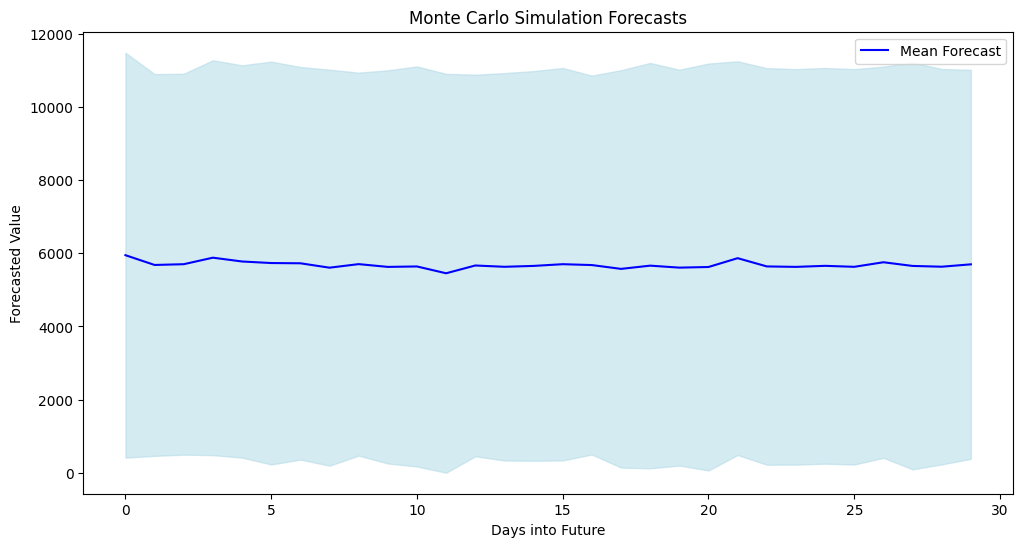

In [20]:
combined_DataFrame.sort_index(inplace=True)
num_simulations = 1000
forecast_steps = 30
simulated_forecasts = np.zeros((num_simulations, forecast_steps))

for i in range(num_simulations):
    residuals = np.random.normal(loc=0, scale=np.std(df['Actual'] - combined_DataFrame['Actual'].mean()), size=forecast_steps)
    simulated_forecasts[i] = combined_DataFrame['Actual'].mean() + residuals

mean_forecasts = simulated_forecasts.mean(axis=0)
std_forecasts = simulated_forecasts.std(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(mean_forecasts, label='Mean Forecast', color='blue')
plt.fill_between(range(forecast_steps), mean_forecasts - 1.96 * std_forecasts, 
                 mean_forecasts + 1.96 * std_forecasts, color='lightblue', alpha=0.5)
plt.title('Monte Carlo Simulation Forecasts')
plt.xlabel('Days into Future')
plt.ylabel('Forecasted Value')
plt.legend()
plt.show()


C:\Users\Chant\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


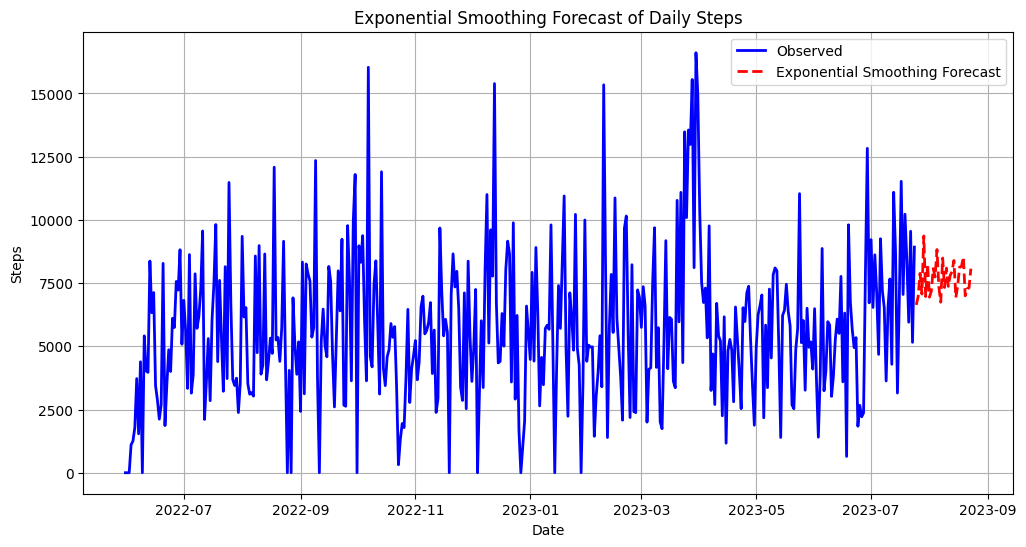

Exponential Smoothing Mean Squared Error (MSE): 59334847.3852
Exponential Smoothing R-squared: 0.0000


In [29]:
if not isinstance(combined_DataFrame.index, pd.DatetimeIndex):
    combined_DataFrame.index = pd.to_datetime(combined_DataFrame.index)

seasonal_periods = min(len(combined_DataFrame) // 2, 30)

if len(combined_DataFrame) < 2 * seasonal_periods:
    print(f"Warning: Data length ({len(combined_DataFrame)}) is less than twice the seasonal period ({seasonal_periods}). Consider adjusting the seasonal period.")

n_forecast_steps = 30

try:
    exponential_model = ExponentialSmoothing(combined_DataFrame['Actual'], seasonal='add', seasonal_periods=seasonal_periods).fit()
    exponential_forecast = exponential_model.forecast(steps=n_forecast_steps)

    forecast_start_date = combined_DataFrame.index[-1] + pd.Timedelta(days=1)
    forecast_index = pd.date_range(start=forecast_start_date, periods=n_forecast_steps, freq='D')

    plt.figure(figsize=(12, 6))
    plt.plot(combined_DataFrame.index, combined_DataFrame['Actual'], label='Observed', color='blue', linewidth=2)
    plt.plot(forecast_index, exponential_forecast, label='Exponential Smoothing Forecast', color='red', linestyle='--', linewidth=2)
    plt.title('Exponential Smoothing Forecast of Daily Steps')
    plt.xlabel('Date')
    plt.ylabel('Steps')
    plt.legend()
    plt.grid(True)
    plt.show()

    actual_values_after_forecast_start = [0] * n_forecast_steps  

    if len(actual_values_after_forecast_start) == n_forecast_steps:
        mse_exponential = mean_squared_error(actual_values_after_forecast_start, exponential_forecast)
        r_squared_exponential = r2_score(actual_values_after_forecast_start, exponential_forecast)

        print(f'Exponential Smoothing Mean Squared Error (MSE): {mse_exponential:.4f}')
        print(f'Exponential Smoothing R-squared: {r_squared_exponential:.4f}')
    else:
        print(f"Length mismatch: {len(actual_values_after_forecast_start)} actual vs. {n_forecast_steps} forecasted values.")
except ValueError as e:
    print(f"Error: {e}")


**Mean Squared Error (MSE):** This high MSE value suggests that the model’s predictions are significantly different from the actual values. The model seems to have a large amount of error in its forecasts.

**R Squared:** An R-squared value of 0.0000 indicates that the model is not explaining any of the variance in the actual values. This is a very poor result, suggesting that the model is not capturing the underlying patterns in my data at all.

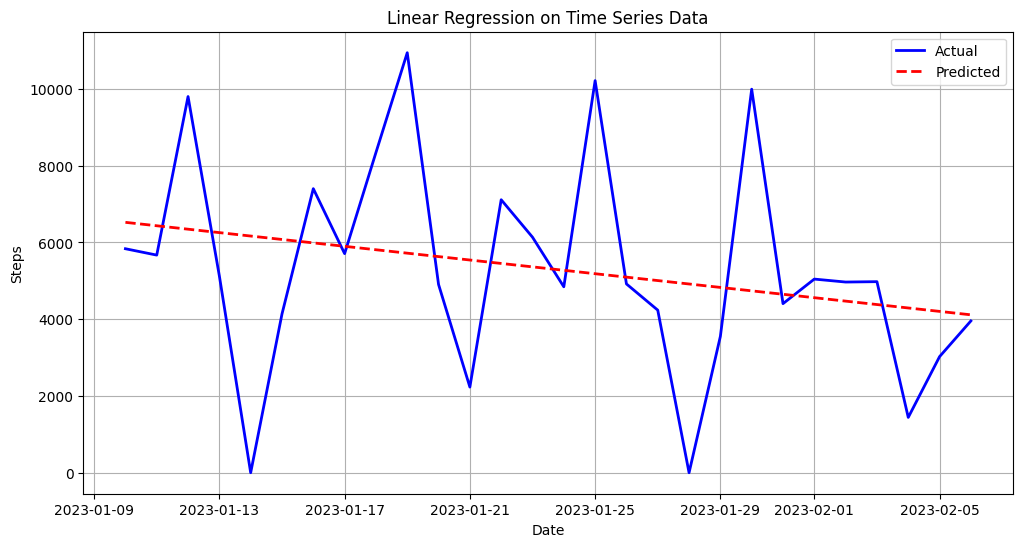

Regression Mean Squared Error (MSE): 7024457.5704
Regression R-squared: 0.0689


In [32]:
prophet_dataf = df.reset_index()[['Date', 'Actual']].rename(columns={'Date': 'ds', 'Actual': 'y'})


prophet_dataf['ds'] = pd.to_datetime(prophet_dataf['ds'])

prophet_dataf['Date_ordinal'] = prophet_dataf['ds'].map(pd.Timestamp.toordinal)

X = prophet_dataf[['Date_ordinal']]
y = prophet_dataf['y']

model = LinearRegression()
model.fit(X, y)

prophet_dataf['Predicted'] = model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(prophet_dataf['ds'], prophet_dataf['y'], label='Actual', color='blue', linewidth=2)
plt.plot(prophet_dataf['ds'], prophet_dataf['Predicted'], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Linear Regression on Time Series Data')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.legend()
plt.grid(True)
plt.show()

mse_regression = mean_squared_error(y, prophet_dataf['Predicted'])
r_squared_regression = r2_score(y, prophet_dataf['Predicted'])

print(f'Regression Mean Squared Error (MSE): {mse_regression:.4f}')
print(f'Regression R-squared: {r_squared_regression:.4f}')


#### The regression model’s performance was evaluated with a Mean Squared Error (MSE) of 7,024,457.57 and an R-squared value of 0.07. The MSE reflects the average squared difference between the predicted and actual values, while the R-squared value indicates that the model explains only about 7% of the variance in the observed data.



# Reflection 

**Decision-Making Process:**

In choosing the models for time series forecasting, several factors were considered:
1. **Model Selection:** I compared ARIMA and SARIMA models based on their Akaike Information Criterion (AIC) values, finding SARIMA to be more effective due to its lower AIC.
2. **Forecasting Models:** I used the Prophet model to forecast daily steps, as it handles time series data with seasonality well.
3. **Error Metrics:** To assess model performance, I calculated Mean Squared Error (MSE) and R-squared values, selecting the model that minimized error and maximized explanatory power.

**Learnings and Insights:**

1. **Model Effectiveness:** SARIMA outperformed ARIMA in forecasting accuracy, indicating its better handling of seasonal patterns. The Prophet model also provided useful forecasts but with different performance metrics.
2. **Error Metrics:** The MSE and R-squared values highlighted the predictive performance and limitations of each model. Prophet showed a lower MSE and higher R-squared compared to the regression model, suggesting better accuracy and fit.
3. **Data Insights:** The time series data’s stationarity and residuals’ analysis revealed insights into the underlying patterns and model assumptions.

**Future Improvements:**

1. **Enhanced Model Tuning:** In future analyses, I will experiment with different hyperparameters and model configurations to optimize performance further.
2. **Data Preprocessing:** Improved data cleaning and preprocessing steps will be implemented to handle missing values and format issues more effectively.
3. **Model Comparison:** I will consider additional models and ensemble methods to validate results and improve forecasting accuracy.

